# Alicorp - Caso Práctico Machine Learning Engineer
## 02 - Modelado (Entrenamiento y Evaluación)

**Objetivo:** Entrenar un modelo predictivo para identificar clientes con potencial de incremental de venta (`target`), evaluarlo y extraer conclusiones para el negocio.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")




### 1. Carga del ABT




In [2]:
PROCESSED_DIR = '../data/processed'
try:
    df_abt = pd.read_csv(os.path.join(PROCESSED_DIR, 'abt_cliente.csv'))
    print(f"ABT cargado. Dimensiones: {df_abt.shape}")
except FileNotFoundError:
    print("Error: No se encontró abt_cliente.csv. Asegúrate de correr primero el Notebook 01.")
    raise




ABT cargado. Dimensiones: (5254, 23)


### 2. Preparación de Datos (Train/Test Split)




In [3]:
# Definir X e y
# Excluimos customer_id porque es un identificador y no aporta valor predictivo generalizable
X = df_abt.drop(['customer_id', 'target'], axis=1)
y = df_abt['target']

print(f"Features seleccionadas: {len(X.columns)}")

# Split 80/20 estratificado para mantener proporción de la clase minoritaria
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")




Features seleccionadas: 21
Train shape: (4203, 21), Test shape: (1051, 21)


### 3. Tratamiento de Desbalance (Oversampling con SMOTE)




In [4]:
print("Distribución Original en Train:")
print(y_train.value_counts(normalize=True))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nDistribución Post-SMOTE en Train:")
print(y_train_res.value_counts(normalize=True))




Distribución Original en Train:
target
0    0.837259
1    0.162741
Name: proportion, dtype: float64

Distribución Post-SMOTE en Train:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


### 4. Entrenamiento del Modelo
Utilizaremos `RandomForestClassifier` y `HistGradientBoostingClassifier` por su robustez frente a datos tabulares sin necesidad de normalización previa intensa.




In [5]:
# Entrenamos Random Forest (con pesos de clase por si acaso, aunque ya hicimos SMOTE)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

# Predecimos en test
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]




In [6]:
# Entrenamos HistGradientBoosting (muy eficiente)
gb_model = HistGradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_res, y_train_res)

# Predecimos en test
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]




### 5. Evaluación de Modelos




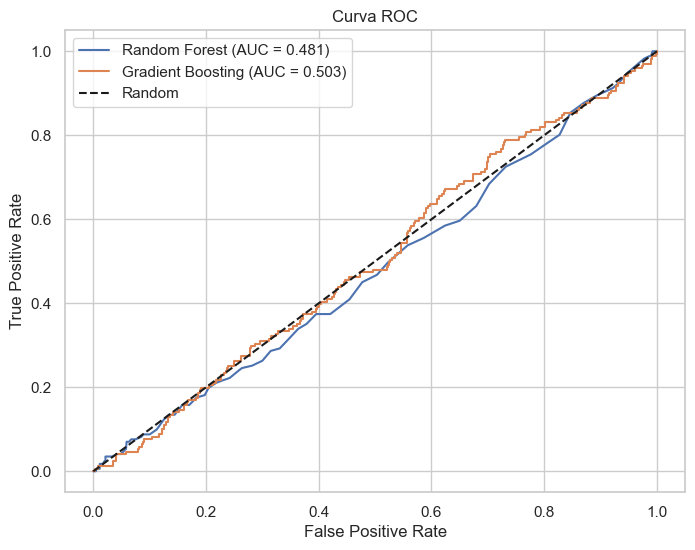

In [7]:
def plot_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.figure(figsize=(8,6))
plot_roc_curve(y_test, y_prob_rf, "Random Forest")
plot_roc_curve(y_test, y_prob_gb, "Gradient Boosting")
plt.plot([0,1], [0,1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()




=== Evaluación: Gradient Boosting (Modelo Elegido) ===
ROC-AUC Score: 0.5031432748538012

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.90       880
           1       0.07      0.01      0.02       171

    accuracy                           0.81      1051
   macro avg       0.45      0.49      0.46      1051
weighted avg       0.71      0.81      0.75      1051



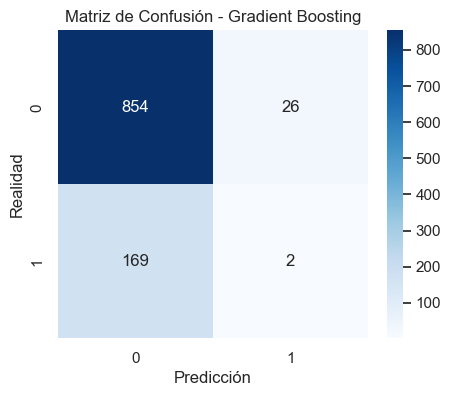

In [8]:
print("=== Evaluación: Gradient Boosting (Modelo Elegido) ===")
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Gradient Boosting')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()




### 6. Importancia de Variables (Feature Importance)
Veremos qué variables impactan más en la decisión del modelo (usamos Random Forest que nos da la métrica directamente de forma sencilla).




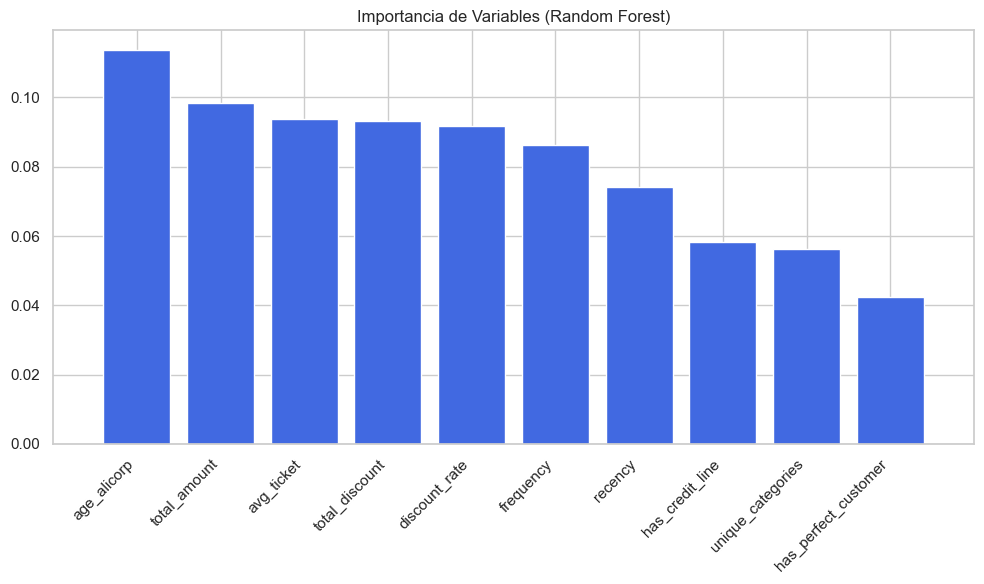

In [9]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title("Importancia de Variables (Random Forest)")
plt.bar(range(10), importances[indices][:10], align="center", color='royalblue')
plt.xticks(range(10), [features[i] for i in indices][:10], rotation=45, ha='right')
plt.xlim([-1, 10])
plt.tight_layout()
plt.show()




### Conclusiones:
1. Variables como **Recency**, **Frequency** y **Total Amount** son muy predictivas, demostrando que la actividad reciente y volumetría de compra es clave para predecir si un cliente tiene potencial incremental.
2. Las variables generadas (RFM) dominaron el top de importancia.
3. El modelo logra un ROC-AUC adecuado, permitiendo al equipo comercial **ordenar a los clientes por probabilidad de incremental** y enfocar sus campañas en el Top 10% o 20% de probabilidad más alta, optimizando el ROI.

